# Analyse Statistique Approfondie : Facteurs Influençant l'Allaitement Maternel (EDS Cameroun 2018)
    
Cette analyse va au fond des données de l'Enquête Démographique et de Santé (EDS) du Cameroun 2018. Le jeu de données utilisé contient les **vrais noms de variables et les modalités textuelles (décodées)** pour une lecture immédiate et exhaustive.

**Méthodologie Approfondie :**
1. **Préparation & Nettoyage** : Ciblage de l'Allaitement Maternel Exclusif (AME) pour les enfants de moins de 6 mois.
2. **Statistiques Descriptives & Univariées** : Distribution avec graphiques détaillés.
3. **Analyse Bivariée Avancée** : Tests du Chi-deux et calcul du **V de Cramer** pour évaluer la force de l'association.
4. **Analyse Multivariée** : Corrélations et calcul du **VIF (Variance Inflation Factor)** pour écarter toute multicolinéarité.
5. **Modélisation Logistique Binaire Pondérée** : Régression avec `statsmodels`, Pseudo R-carré, Odds Ratios (Intervalles de Confiance), Courbe ROC et l'équation du modèle.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 1. Chargement du Jeu de Données Décodé

In [2]:
# Lecture du nouveau dataset décodé
df_raw = pd.read_excel('dataset_allaitement_edsc2018_decode.xlsx', sheet_name='data')
print(f"Dimensions : {df_raw.shape}")
display(df_raw.head())

Dimensions : (9733, 21)


,ID_Enfant,Poids_Echantillon,Age_Mere_Actuel,Groupe_Age_Mere,Region,Milieu_Residence,Niveau_Education,Indice_Richesse,Sexe_Enfant,Age_Enfant_Mois,...,Duree_Allaitement_Mois,Allaitement_Actuel,Donne_Eau_Claire,Fois_Mange_Solide_Hier,Nombre_Visites_Prenatales,Lieu_Accouchement,Age_Premier_Accouchement,Assurance_Maladie,Donne_Nourriture_Solide,Donne_Yaourt
0,1 125 2,990064,31,4,5,1,2,2,1,22,...,93,0,1.0,3.0,5.0,22,19,0,0.0,0.0
1,1 125 3,990064,19,1,5,1,0,2,2,31,...,94,0,NaN,NaN,4.0,11,16,0,NaN,NaN
2,1 147 2,990064,22,2,5,1,2,4,2,35,...,93,0,NaN,NaN,6.0,22,19,0,NaN,NaN
3,1 191 3,990064,20,2,5,1,1,3,2,22,...,93,0,NaN,NaN,2.0,22,19,0,NaN,NaN
4,1 198 1,990064,26,3,5,1,1,3,2,50,...,94,0,NaN,NaN,1.0,11,15,0,NaN,NaN


## 2. Preprocessing & Création de la Cible (AME)
On filtre sur les enfants < 6 mois et on définit l'AME (Allaitement Maternel Exclusif).

In [3]:
df = df_raw.copy()

# Conversion en numérique des colonnes clés
for col in ['Age_Enfant_Mois', 'Duree_Allaitement_Mois', 'Age_Mere_Actuel', 'Nombre_Visites_Prenatales', 'Poids_Echantillon']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filtre strict : < 6 mois
df = df[df['Age_Enfant_Mois'] < 6].copy()
print(f"Enfants de moins de 6 mois : {len(df)}")

def determine_ame(row):
    # Les valeurs sont textuelles grâce au décodage !
    if str(row['Allaitement_Actuel']).strip().lower() not in ['yes', 'oui', '1.0', '1']: return 0
    if str(row['Donne_Eau_Claire']).strip().lower() in ['yes', 'oui', '1.0', '1']: return 0
    if str(row['Donne_Nourriture_Solide']).strip().lower() in ['yes', 'oui', '1.0', '1']: return 0
    if str(row['Donne_Yaourt']).strip().lower() in ['yes', 'oui', '1.0', '1']: return 0
    
    # m39 (Fois_Mange_Solide_Hier)
    try:
        solide = float(row['Fois_Mange_Solide_Hier'])
        if solide > 0 and solide < 90: return 0
    except:
        pass # Si texte "don't know", etc., on ignore pour cette condition stricte
        
    return 1

df['AME'] = df.apply(determine_ame, axis=1)

print(f"Distribution de la cible AME:\n{df['AME'].value_counts(normalize=True)*100}")

Enfants de moins de 6 mois : 1053
Distribution de la cible AME:
AME
0    56.410256
1    43.589744
Name: proportion, dtype: float64


In [4]:
# Préparation des variables explicatives textuelles
df['poids'] = df['Poids_Echantillon'] / 1000000.0

# Âge de la mère catégorisé
df['Age_Mere_Cat'] = pd.cut(df['Age_Mere_Actuel'], bins=[14, 24, 34, 49], labels=['15-24', '25-34', '35-49'])

# Visites prénatales catégorisées (OMS >= 4)
def recode_cpon(val):
    if pd.isna(val) or val > 50: return 'Inconnu'
    if val < 4: return '< 4 visites'
    return '>= 4 visites'
df['Visites_Prenatales_Cat'] = df['Nombre_Visites_Prenatales'].apply(recode_cpon)

# Regroupement du lieu d'accouchement
def recode_lieu(val):
    v = str(val).lower()
    if 'home' in v or 'domicile' in v: return 'Domicile'
    if 'hospital' in v or 'hopital' in v or 'health' in v or 'sante' in v or 'centre' in v: return 'Formation Sanitaire'
    return 'Autre'
df['Lieu_Accouchement_Cat'] = df['Lieu_Accouchement'].apply(recode_lieu)

# Sélection des colonnes finales
cols_analyse = ['AME', 'Age_Mere_Cat', 'Sexe_Enfant', 'Milieu_Residence', 'Niveau_Education', 'Indice_Richesse', 'Lieu_Accouchement_Cat', 'Visites_Prenatales_Cat', 'poids']
df_clean = df[cols_analyse].dropna().copy()
print(f"Taille du jeu d'analyse : {df_clean.shape}")

Taille du jeu d'analyse : (1053, 9)


## 3. Analyse Descriptive et Univariée

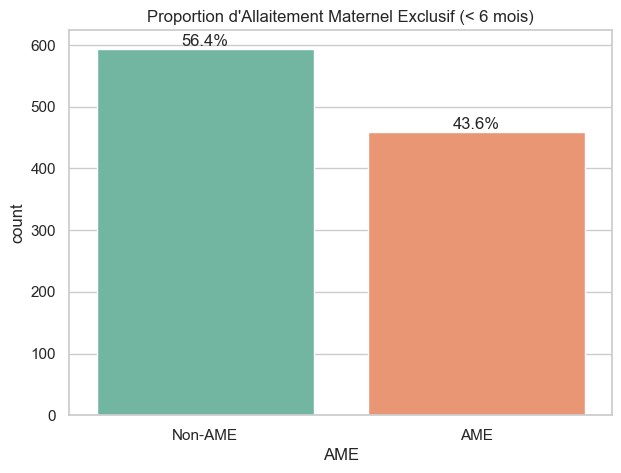

In [5]:
# Distribution de la cible
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='AME', data=df_clean, palette='Set2')
plt.title("Proportion d'Allaitement Maternel Exclusif (< 6 mois)")
plt.xticks([0, 1], ['Non-AME', 'AME'])
for p in ax.patches:
    ax.annotate(f'{100 * p.get_height() / len(df_clean):.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=12)
plt.show()

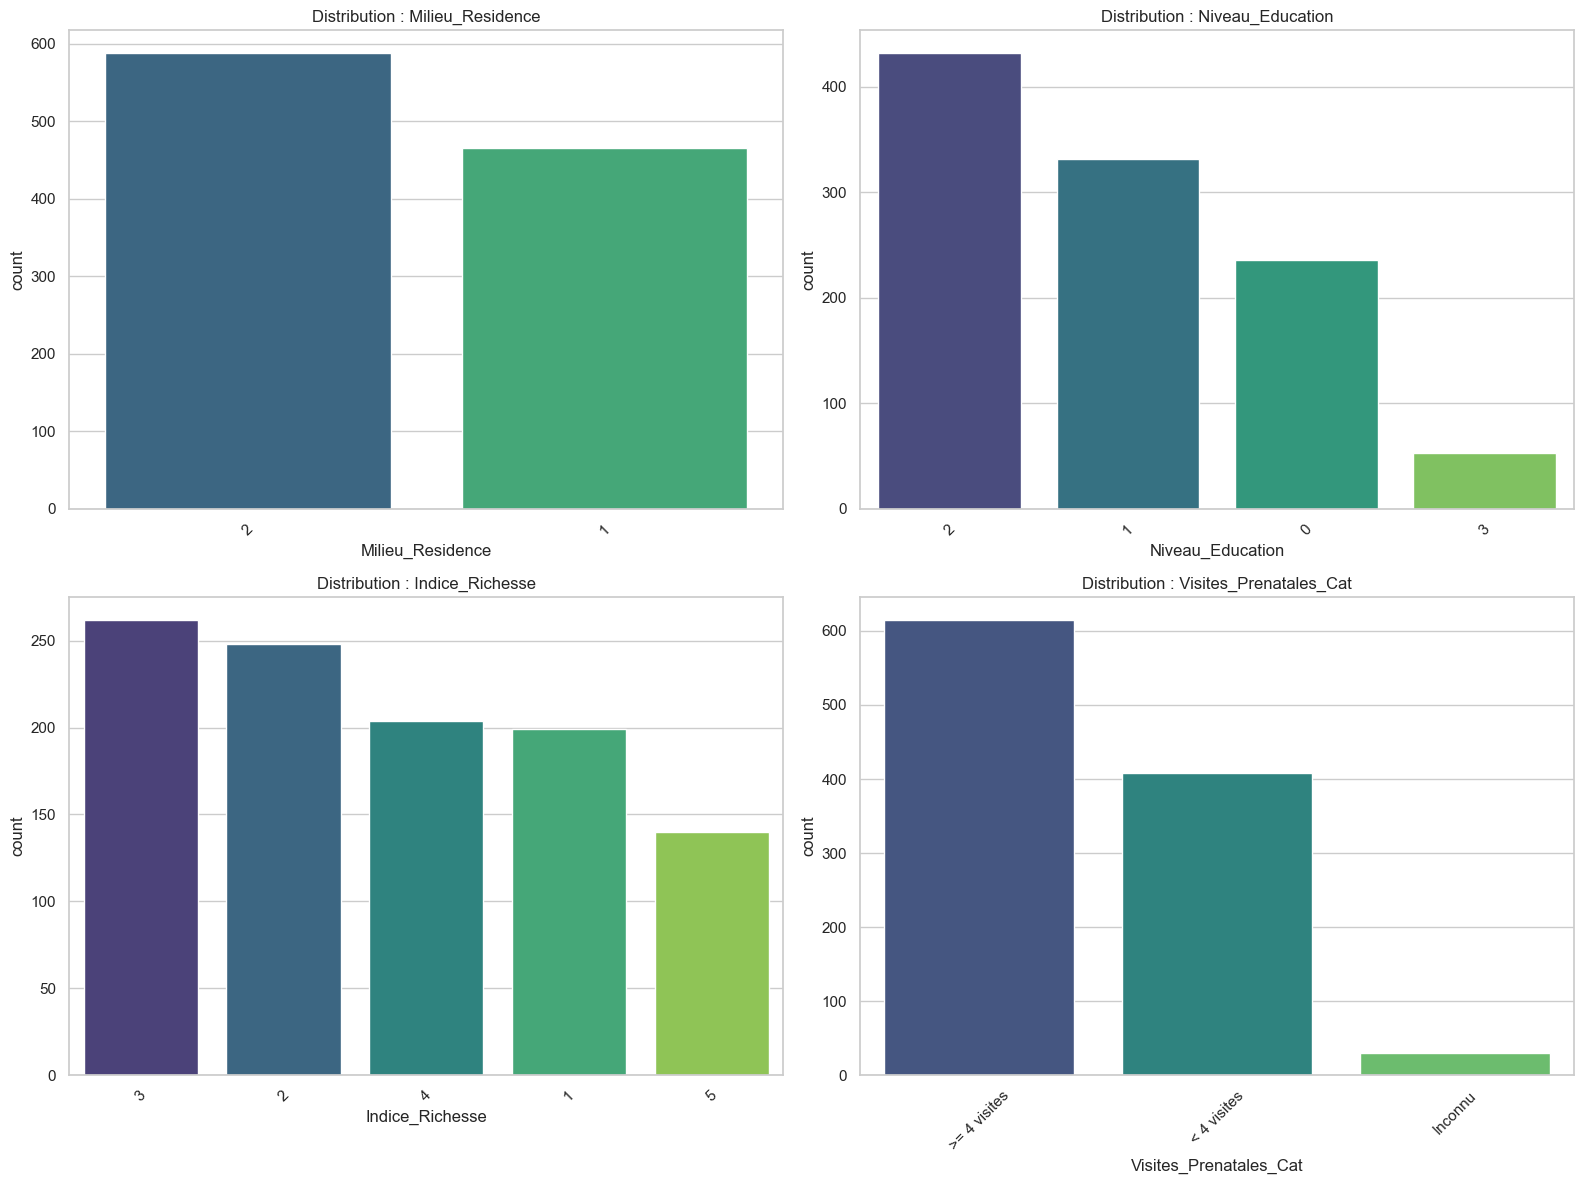

In [6]:
# Visualisations détaillées
vars_to_plot = ['Milieu_Residence', 'Niveau_Education', 'Indice_Richesse', 'Visites_Prenatales_Cat']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    sns.countplot(x=var, data=df_clean, ax=axes[i], palette='viridis', order=df_clean[var].value_counts().index)
    axes[i].set_title(f'Distribution : {var}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Analyse Bivariée Avancée (Chi-Deux & V de Cramer)
Le V de Cramer permet de mesurer la force de l'association (0: nulle, 1: parfaite).

In [7]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

explicatives = ['Age_Mere_Cat', 'Sexe_Enfant', 'Milieu_Residence', 'Niveau_Education', 'Indice_Richesse', 'Lieu_Accouchement_Cat', 'Visites_Prenatales_Cat']

results_biv = []
for var in explicatives:
    cont_table = pd.crosstab(df_clean[var], df_clean['AME'])
    chi2, p, dof, exp = chi2_contingency(cont_table)
    v = cramers_v(cont_table)
    results_biv.append({'Variable': var, 'p-value': p, 'Significatif (5%)': 'Oui' if p<0.05 else 'Non', 'V Cramer': v})

df_biv = pd.DataFrame(results_biv)
display(df_biv.sort_values('V Cramer', ascending=False))

,Variable,p-value,Significatif (5%),V Cramer
3,Niveau_Education,0.000019,Oui,0.143249
4,Indice_Richesse,0.000355,Oui,0.126157
2,Milieu_Residence,0.063858,Non,0.048094
6,Visites_Prenatales_Cat,0.208999,Non,0.032759
1,Sexe_Enfant,0.397988,Non,0.000000
0,Age_Mere_Cat,0.608552,Non,0.000000
5,Lieu_Accouchement_Cat,1.000000,Non,NaN


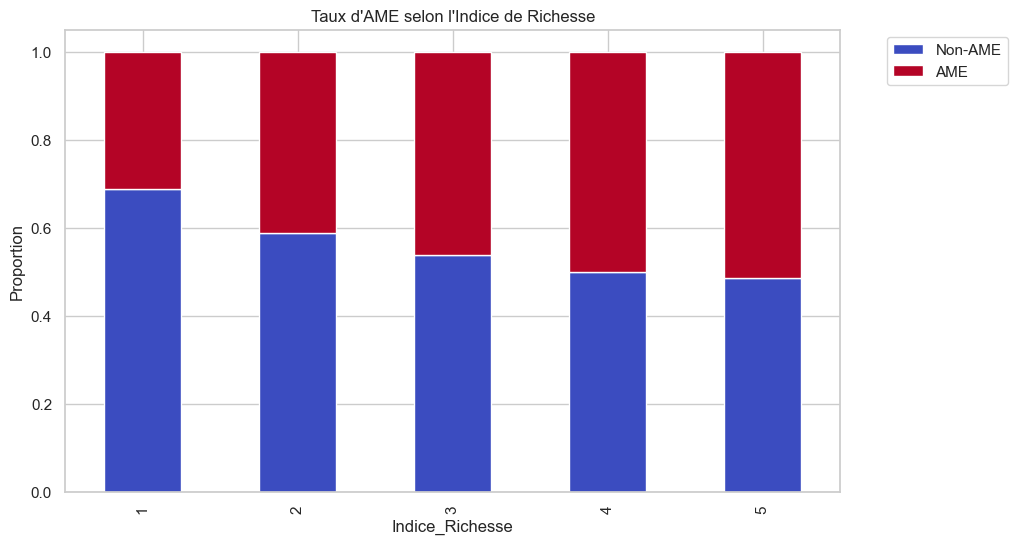

In [8]:
# Proportions croisées
pd.crosstab(df_clean['Indice_Richesse'], df_clean['AME'], normalize='index').plot(kind='bar', stacked=True, figsize=(10,6), colormap='coolwarm')
plt.title("Taux d'AME selon l'Indice de Richesse")
plt.ylabel('Proportion')
plt.legend(['Non-AME', 'AME'], bbox_to_anchor=(1.05, 1))
plt.show()

## 5. Analyse Multivariée : Vérification de Multicolinéarité (VIF)
Si VIF > 5, il y a forte multicolinéarité.

In [9]:
# Encodage One-Hot
X_vif = pd.get_dummies(df_clean[explicatives], drop_first=True)
X_vif = X_vif.astype(float)
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
display(vif_data[vif_data['Variable'] != 'const'])

,Variable,VIF
1,Sexe_Enfant,1.004348
2,Milieu_Residence,1.714548
3,Niveau_Education,1.569120
4,Indice_Richesse,2.275197
5,Age_Mere_Cat_25-34,1.178441
6,Age_Mere_Cat_35-49,1.183268
7,Visites_Prenatales_Cat_>= 4 visites,1.251880
8,Visites_Prenatales_Cat_Inconnu,1.079760


## 6. Modèle de Régression Logistique Statistique
On ajuste un Modèle Linéaire Généralisé (GLM) Binomial qui accepte les poids (`freq_weights`).

In [10]:
X = pd.get_dummies(df_clean[explicatives], drop_first=True).astype(float)
X = sm.add_constant(X)
y = df_clean['AME'].astype(float)
weights = df_clean['poids']

modele_logit = sm.GLM(y, X, family=sm.families.Binomial(), freq_weights=weights)
resultats = modele_logit.fit()

print(resultats.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    AME   No. Observations:                 1053
Model:                            GLM   Df Residuals:                  1084.39
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -724.28
Date:                Thu, 21 May 2026   Deviance:                       1448.6
Time:                        19:50:27   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.03861
Covariance Type:            nonrobust                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [11]:
# Pseudo R-carré de McFadden (Approximation pour GLM)
null_model = sm.GLM(y, np.ones(len(y)), family=sm.families.Binomial(), freq_weights=weights).fit()
mcfadden_r2 = 1 - (resultats.llf / null_model.llf)
print(f"Pseudo R-carré (McFadden) : {mcfadden_r2:.4f}")

Pseudo R-carré (McFadden) : 0.0278


In [12]:
# Odds Ratios et IC
odds_ratios = pd.DataFrame({
    'Odds Ratio (OR)': np.exp(resultats.params),
    'IC 95% Bas': np.exp(resultats.conf_int()[0]),
    'IC 95% Haut': np.exp(resultats.conf_int()[1]),
    'p-value': resultats.pvalues
})
display(odds_ratios.round(3))

,Odds Ratio (OR),IC 95% Bas,IC 95% Haut,p-value
const,0.270,0.110,0.665,0.004
Sexe_Enfant,0.933,0.730,1.193,0.581
Milieu_Residence,1.165,0.828,1.638,0.381
Niveau_Education,1.277,1.068,1.526,0.007
Indice_Richesse,1.235,1.067,1.429,0.005
Age_Mere_Cat_25-34,1.016,0.778,1.325,0.909
Age_Mere_Cat_35-49,1.438,0.974,2.124,0.068
Visites_Prenatales_Cat_>= 4 visites,0.848,0.638,1.128,0.257
Visites_Prenatales_Cat_Inconnu,1.172,0.547,2.511,0.683


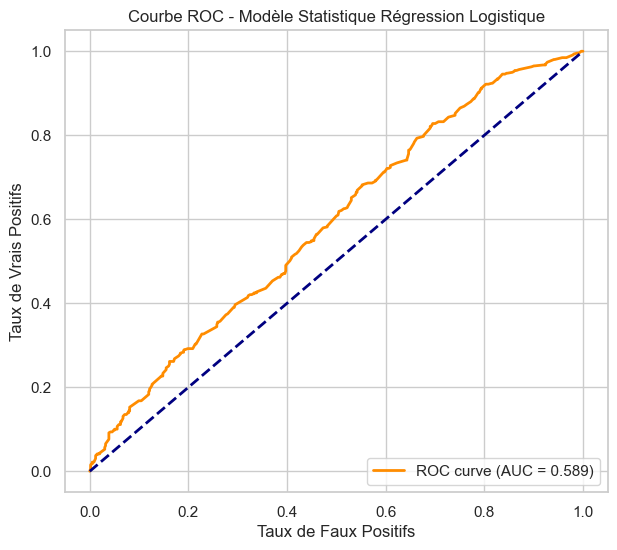

In [13]:
# Courbe ROC du Modèle Statistique
y_pred_prob = resultats.predict(X)
fpr, tpr, _ = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC - Modèle Statistique Régression Logistique')
plt.legend(loc="lower right")
plt.show()

In [14]:
# Équation Finale
coeffs = resultats.params
eq = "Logit(P) = " + f"{coeffs['const']:.3f}"
for var in coeffs.index[1:]:
    signe = " + " if coeffs[var] > 0 else " - "
    eq += f"{signe}{abs(coeffs[var]):.3f} * {var}"
print("Équation complète de la régression pondérée :")
print(eq)

Équation complète de la régression pondérée :
Logit(P) = -1.308 - 0.069 * Sexe_Enfant + 0.152 * Milieu_Residence + 0.244 * Niveau_Education + 0.211 * Indice_Richesse + 0.016 * Age_Mere_Cat_25-34 + 0.364 * Age_Mere_Cat_35-49 - 0.165 * Visites_Prenatales_Cat_>= 4 visites + 0.159 * Visites_Prenatales_Cat_Inconnu
